# Un vidrio con la fuerza del diamante y la tenacidad de un metal

**6.43 GPa.** Eso es lo que aguantan estos vidrios metálicos antes de romperse — más que casi cualquier metal y al borde del diamante policristalino. Pero a diferencia del diamante, no se rompen como cristal: se deforman, absorben energía, sobreviven al impacto.

> Ceramic-like strength and metallic toughness in a bulk metallic glass · Cai et al. · *Nature*, 2026 · DOI: [10.1038/s41586-026-10430-w](https://doi.org/10.1038/s41586-026-10430-w)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-22-vidrio-metalico-resistencia-ceramica/notebook.ipynb)

[Video relacionado: pendiente]


## El trade-off que llevaba décadas estancado

Las cerámicas son resistentes pero frágiles: si las golpeas, se astillan. Los metales son tenaces pero blandos: aguantan el golpe pero se deforman bajo carga. Los ingenieros llevan décadas intentando combinar lo mejor de los dos. Lo nuevo aquí es un **vidrio metálico masivo (BMG)** basado en renio, cobalto, tántalo y boro — Re-Co-Ta-B — fabricado por colada por succión en moldes de cobre.

El equipo midió cinco composiciones. La que rinde mejor (Re1, con 26.8% de Re) llega a **6.43 GPa de resistencia a la fractura** y **30 MPa·m^1/2 de tenacidad**. En el plano resistencia-tenacidad, esa combinación cae en una región que hasta ahora estaba prácticamente vacía. Veámoslo con sus propios datos.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
SIGMA_Y_THIS_WORK = 6.43       # Resistencia a la fractura (GPa)
K1C_THIS_WORK     = 30.0       # Tenacidad a la fractura (MPa·m^1/2)
TEMP_REFERENCIA   = 900        # Kelvin — el banco de prueba para alta T
FUENTE = 'Fuente: Cai et al. (2026), Nature | Datos: Supplementary Tables S1, S2, S6'

COLOR_THIS_WORK   = '#DC2626'  # Re-Co-Ta-B — el protagonista
COLOR_CERAMIC     = '#7C3AED'  # cerámicas (frágiles)
COLOR_BMG         = '#2563EB'  # otros vidrios metálicos
COLOR_CRYSTALLINE = '#059669'  # aleaciones cristalinas

# ──────────────────────────────────────────────────────────────
# Imports + estilo CaM
# ──────────────────────────────────────────────────────────────
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file
        )
plt.style.use(style_file)

# ──────────────────────────────────────────────────────────────
# Carga de los 3 datasets
# ──────────────────────────────────────────────────────────────
df_st  = pd.read_csv('datos/strength_toughness.csv')
df_t   = pd.read_csv('datos/strength_vs_temperature.csv')
df_cmp = pd.read_csv('datos/composiciones_re_co_ta_b.csv')

print(f"Materiales en el plano σy–K1C: {len(df_st)}")
print(f"  · cerámicas:          {(df_st['categoria']=='ceramic').sum()}")
print(f"  · BMGs (otros):       {(df_st['categoria']=='bmg').sum()}")
print(f"  · aleaciones cristal: {(df_st['categoria']=='crystalline_alloy').sum()}")
print(f"  · this_work:          {(df_st['categoria']=='this_work').sum()}")
print(f"\nMediciones strength vs T: {len(df_t)} puntos / {df_t['material'].nunique()} materiales")
print(f"Composiciones sintetizadas: {len(df_cmp)}")


Materiales en el plano σy–K1C: 72
  · cerámicas:          23
  · BMGs (otros):       43
  · aleaciones cristal: 5
  · this_work:          1

Mediciones strength vs T: 98 puntos / 16 materiales
Composiciones sintetizadas: 5


## El mapa Ashby

Aquí está. Una sola gráfica que resume por qué este paper importa.


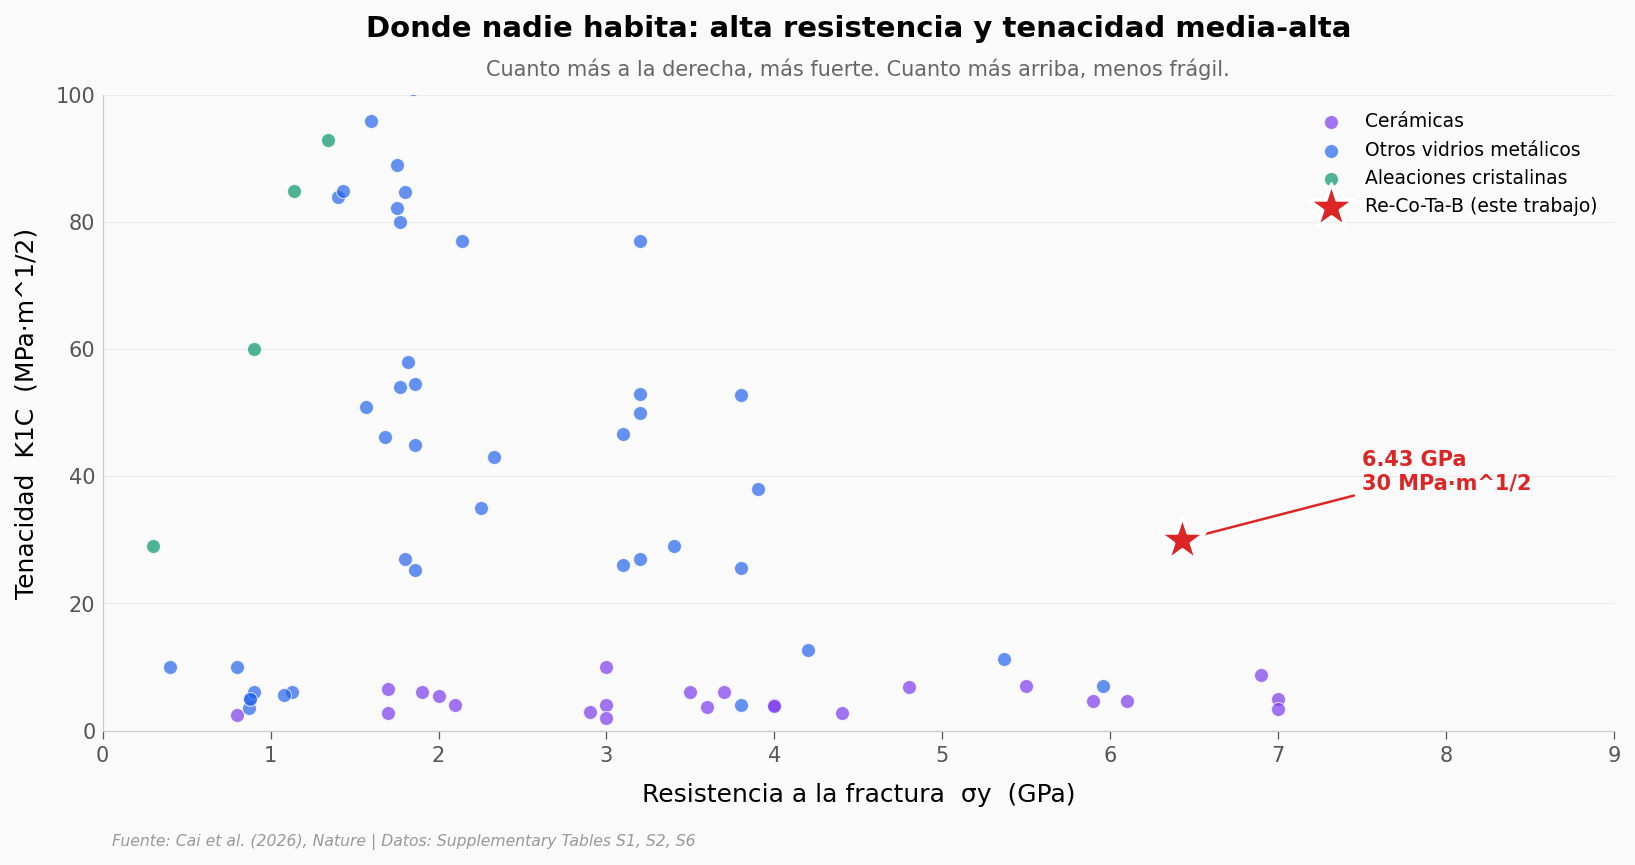

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

categorias = [
    ('ceramic',           'Cerámicas',          COLOR_CERAMIC),
    ('bmg',               'Otros vidrios metálicos', COLOR_BMG),
    ('crystalline_alloy', 'Aleaciones cristalinas',  COLOR_CRYSTALLINE),
]
for cat, label, color in categorias:
    sub = df_st[df_st['categoria'] == cat]
    ax.scatter(sub['yield_strength_gpa'], sub['fracture_toughness_mpa_m12'],
               color=color, s=45, alpha=0.7, edgecolors='white', linewidths=0.5,
               label=label, zorder=4)

# This work — destacado
tw = df_st[df_st['categoria'] == 'this_work'].iloc[0]
ax.scatter(tw['yield_strength_gpa'], tw['fracture_toughness_mpa_m12'],
           marker='*', s=520, color=COLOR_THIS_WORK,
           edgecolors='white', linewidths=1.5, zorder=10,
           label='Re-Co-Ta-B (este trabajo)')
ax.annotate('6.43 GPa\n30 MPa·m^1/2',
            xy=(tw['yield_strength_gpa'], tw['fracture_toughness_mpa_m12']),
            xytext=(7.5, 38), fontsize=10, fontweight='bold', color=COLOR_THIS_WORK,
            arrowprops=dict(arrowstyle='-', color=COLOR_THIS_WORK, lw=1.2))

ax.set_xlabel('Resistencia a la fractura  σy  (GPa)')
ax.set_ylabel('Tenacidad  K1C  (MPa·m^1/2)')
ax.set_title('Donde nadie habita: alta resistencia y tenacidad media-alta',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cuanto más a la derecha, más fuerte. Cuanto más arriba, menos frágil.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 9)
ax.set_ylim(0, 100)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ashby_strength_toughness.png', dpi=200, bbox_inches='tight')
plt.show()


Lo que llama la atención no es solo la posición del Re-Co-Ta-B — es la región vacía que ocupa. Por debajo de 6 GPa el plano está saturado: cerámicas duras pero frágiles, BMGs convencionales con tenacidades por encima de 20 pero resistencias modestas, aleaciones cristalinas tenaces pero blandas. El cuadrante superior-derecho (alta σy, K1C ≥ 20) es territorio prácticamente desocupado.

Solo tres cerámicas alcanzan o superan los 6.43 GPa de σy: c-BN (7.0 GPa) y dos PCDs (diamante policristalino, 6.9 y 7.0 GPa). Ninguna pasa de K1C = 9. La que mejor combina las dos es PCD con 6.9 GPa + 8.8 MPa·m^1/2 — y aun así, la tenacidad del Re-BMG la triplica (30 / 8.8 ≈ 3.4×).


## ¿Y al calor?

A temperatura ambiente todo se ve bien. Pero los BMGs tienen un problema histórico: cerca de su temperatura de transición vítrea (Tg) fluyen viscosamente y la resistencia se desploma. Los superalloys (Inconel, Haynes) y los aceros refractarios aguantan más, pero parten de resistencias muy bajas. Veamos cómo sobrevive este Re-Co-Ta-B comparado con sus rivales naturales.


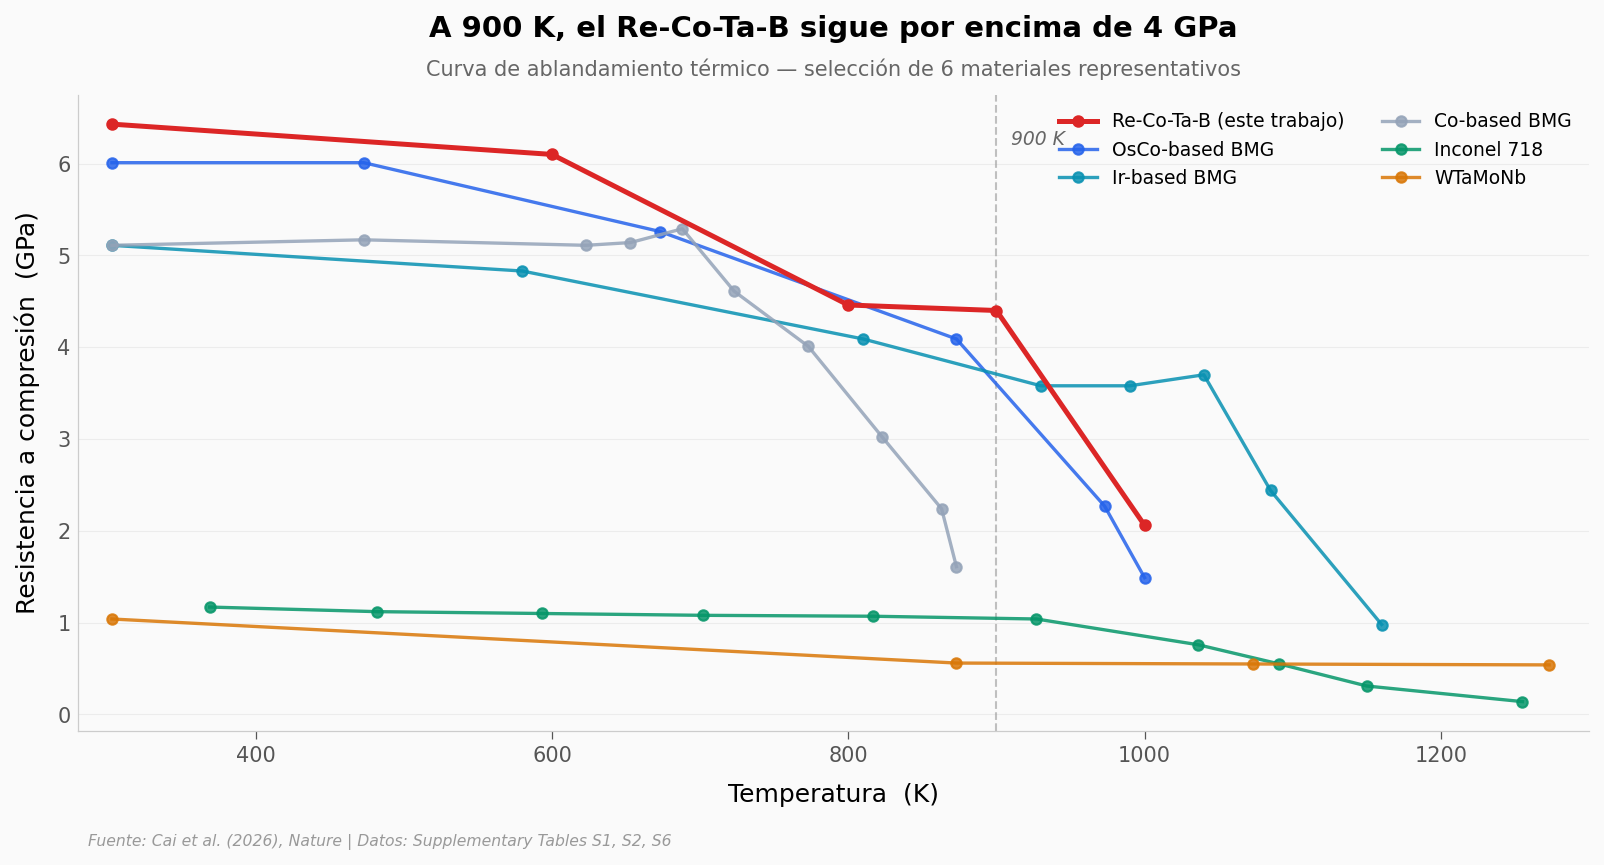

σy a 303 K:  6.43 GPa
σy a 900 K:  4.40 GPa  (caída del 31.6%)
σy a 1000 K: 2.06 GPa  (caída del 68.0%)


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Selección curada — los rivales más relevantes (no los 16 a la vez)
seleccion = {
    'Re-based BMG (This work)': COLOR_THIS_WORK,
    'OsCo-based BMG':           '#2563EB',
    'Ir-based BMG':             '#0891B2',
    'Co-based BMG':             '#94A3B8',
    'Inconel 718':              '#059669',
    'WTaMoNb':                  '#D97706',
}

for material, color in seleccion.items():
    sub = df_t[df_t['material'] == material].sort_values('temperatura_k')
    if len(sub) == 0:
        continue
    is_this = 'This work' in material
    lw = 2.4 if is_this else 1.6
    z  = 10 if is_this else 4
    alpha = 1.0 if is_this else 0.85
    label = 'Re-Co-Ta-B (este trabajo)' if is_this else material
    ax.plot(sub['temperatura_k'], sub['strength_gpa'],
            marker='o', markersize=5, color=color, linewidth=lw,
            alpha=alpha, label=label, zorder=z)

# Línea vertical en 900 K
ax.axvline(x=TEMP_REFERENCIA, color='#999999', linestyle='--', linewidth=1.0, alpha=0.6, zorder=2)
ax.text(TEMP_REFERENCIA + 10, ax.get_ylim()[1] * 0.92,
        f'{TEMP_REFERENCIA} K', fontsize=9, color='#666666', style='italic')

ax.set_xlabel('Temperatura  (K)')
ax.set_ylabel('Resistencia a compresión  (GPa)')
ax.set_title('A 900 K, el Re-Co-Ta-B sigue por encima de 4 GPa',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Curva de ablandamiento térmico — selección de 6 materiales representativos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(280, 1300)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9, ncol=2)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/strength_vs_temperature.png', dpi=200, bbox_inches='tight')
plt.show()

# Cuantificar la caída del this_work
tw_curve = df_t[df_t['material'] == 'Re-based BMG (This work)'].sort_values('temperatura_k')
s_303  = tw_curve[tw_curve['temperatura_k'] == 303]['strength_gpa'].values[0]
s_900  = tw_curve[tw_curve['temperatura_k'] == 900]['strength_gpa'].values[0]
s_1000 = tw_curve[tw_curve['temperatura_k'] == 1000]['strength_gpa'].values[0]
print(f"σy a 303 K:  {s_303:.2f} GPa")
print(f"σy a 900 K:  {s_900:.2f} GPa  (caída del {(1-s_900/s_303)*100:.1f}%)")
print(f"σy a 1000 K: {s_1000:.2f} GPa  (caída del {(1-s_1000/s_303)*100:.1f}%)")


## Cinco recetas, cinco compromisos

El Re-Co-Ta-B no es una composición fija. El equipo sintetizó cinco variantes (Re1 a Re5) cambiando ligeramente la proporción de cada elemento. En las cinco recetas, más renio tiende a subir la temperatura de transición vítrea (Tg) — el techo térmico del material. Pero el espesor crítico de colada (dc, qué tan grueso pueden hacerlo sin que cristalice) baja. Hay que elegir.


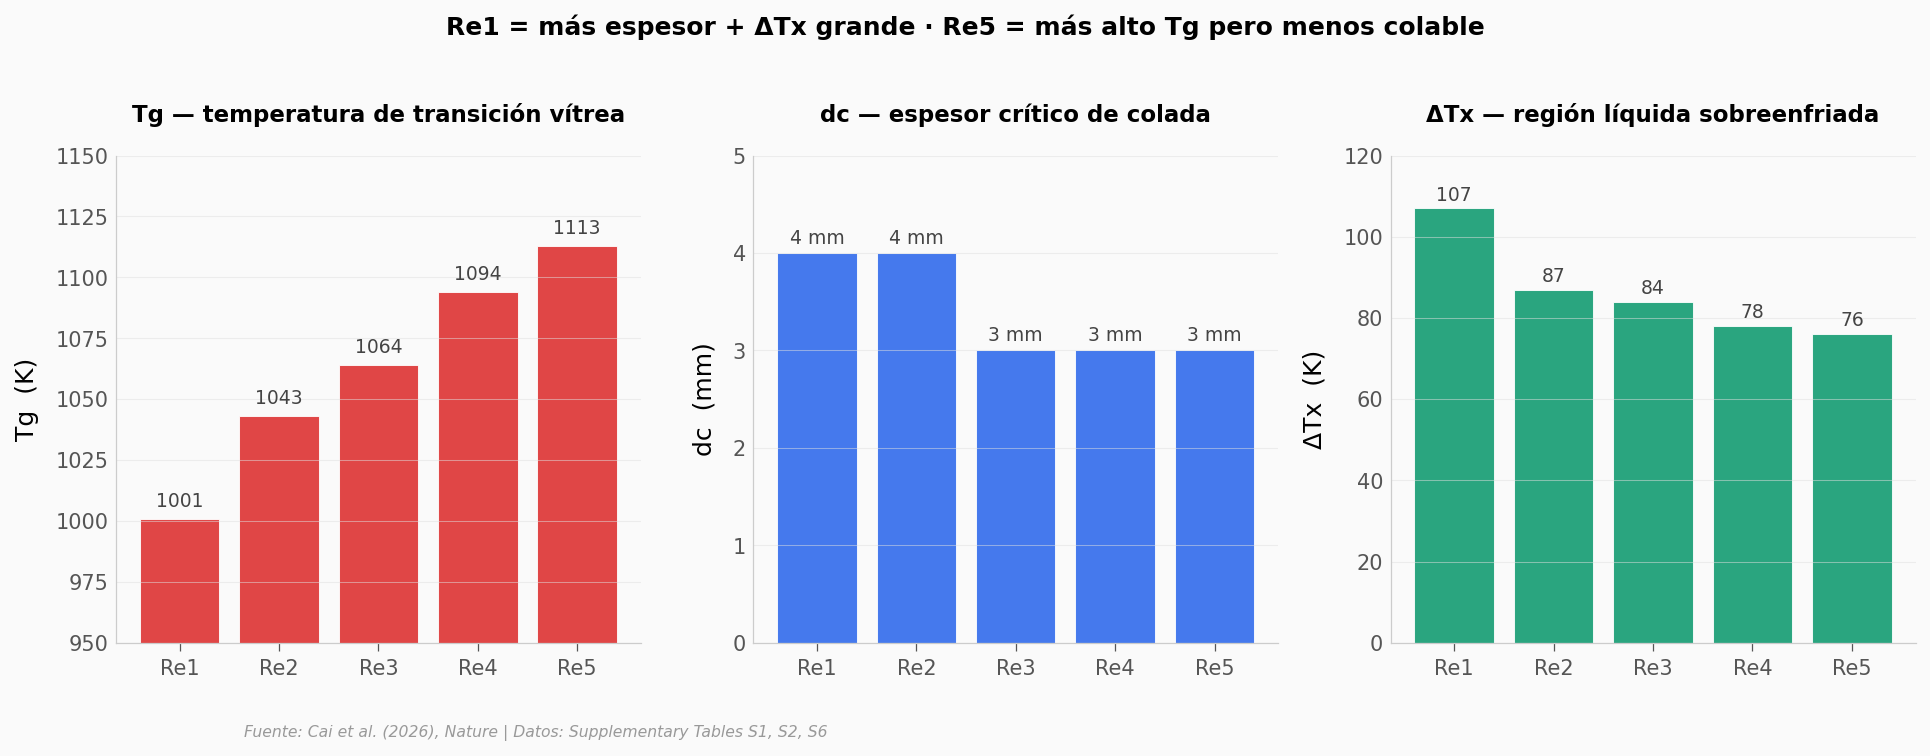

Correlación Spearman (Re% vs Tg): ρ = 1.000, p = 0.0000  (n = 5)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

x = np.arange(len(df_cmp))
labels = df_cmp['etiqueta'].values

# Panel 1 — Tg (techo térmico)
axes[0].bar(x, df_cmp['tg_k'], color=COLOR_THIS_WORK, alpha=0.85, edgecolor='white')
axes[0].set_ylim(950, 1150)
axes[0].set_title('Tg — temperatura de transición vítrea', fontsize=11, fontweight='bold', pad=16)
axes[0].set_ylabel('Tg  (K)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
for i, v in enumerate(df_cmp['tg_k']):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9, color='#444444')

# Panel 2 — dc (espesor máximo sin cristalizar)
axes[1].bar(x, df_cmp['dc_mm'], color=COLOR_BMG, alpha=0.85, edgecolor='white')
axes[1].set_ylim(0, 5)
axes[1].set_title('dc — espesor crítico de colada', fontsize=11, fontweight='bold', pad=16)
axes[1].set_ylabel('dc  (mm)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
for i, v in enumerate(df_cmp['dc_mm']):
    axes[1].text(i, v + 0.1, f'{v} mm', ha='center', fontsize=9, color='#444444')

# Panel 3 — ΔTx (estabilidad del líquido sobreenfriado)
axes[2].bar(x, df_cmp['delta_tx_k'], color='#059669', alpha=0.85, edgecolor='white')
axes[2].set_ylim(0, 120)
axes[2].set_title('ΔTx — región líquida sobreenfriada', fontsize=11, fontweight='bold', pad=16)
axes[2].set_ylabel('ΔTx  (K)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
for i, v in enumerate(df_cmp['delta_tx_k']):
    axes[2].text(i, v + 2, str(v), ha='center', fontsize=9, color='#444444')

fig.suptitle('Re1 = más espesor + ΔTx grande · Re5 = más alto Tg pero menos colable',
             fontsize=12, fontweight='bold', y=1.02)

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/composiciones.png', dpi=200, bbox_inches='tight')
plt.show()

# Correlación Re% ↔ Tg
from scipy import stats
r, p = stats.spearmanr(df_cmp['re_pct'], df_cmp['tg_k'])
print(f"Correlación Spearman (Re% vs Tg): ρ = {r:.3f}, p = {p:.4f}  (n = {len(df_cmp)})")


## ¿Qué tan rara es esa tenacidad?

Entre todos los materiales con resistencia ≥ 5 GPa — la zona del mapa donde casi todo es cerámica frágil — ¿dónde queda el Re-Co-Ta-B en términos de tenacidad?


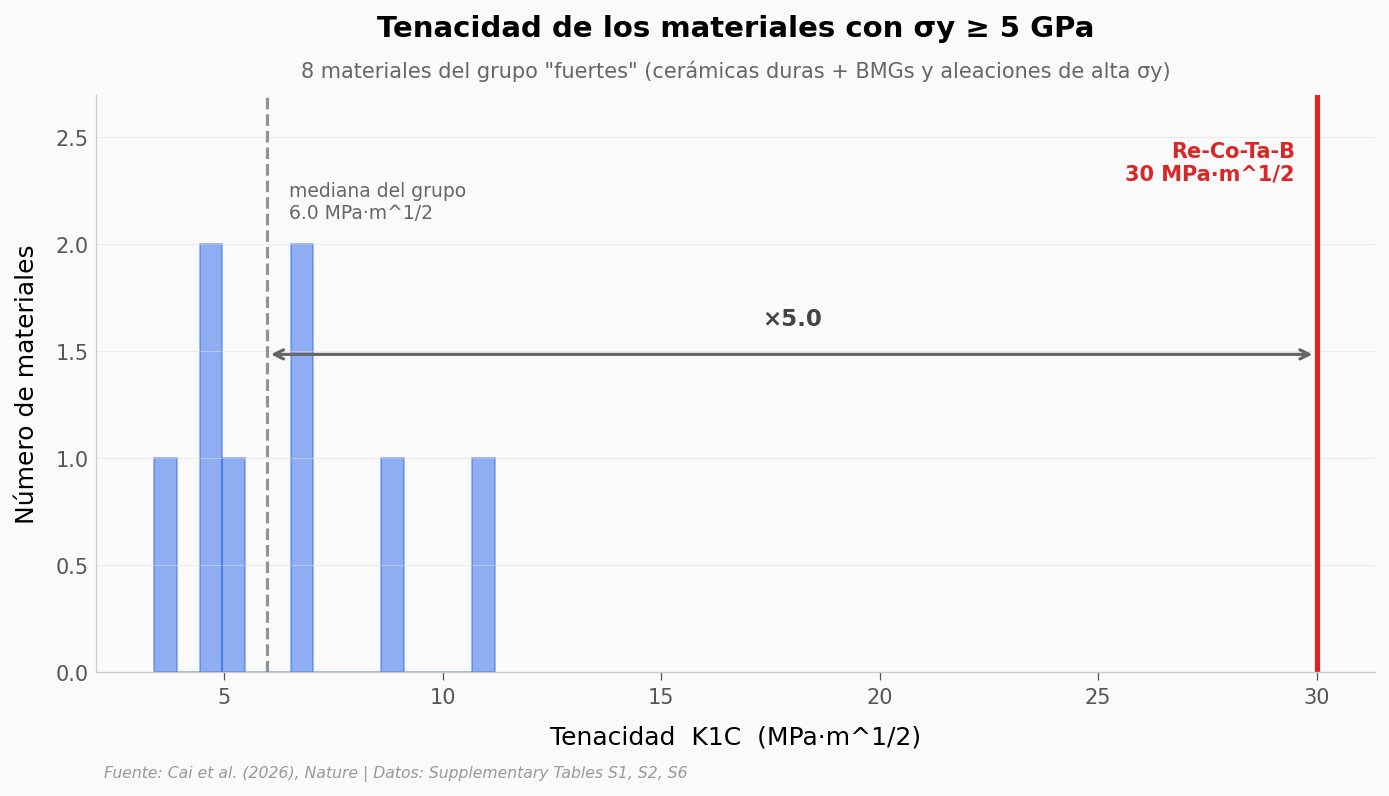

Materiales fuertes (σy ≥ 5 GPa): n = 8
  · K1C mínimo:  3.4 MPa·m^1/2
  · K1C mediano: 6.0 MPa·m^1/2
  · K1C máximo:  11.2 MPa·m^1/2
  · Re-Co-Ta-B:  30 MPa·m^1/2  (×5.0 la mediana)


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

# Subset: materiales con σy >= 5 GPa (excluye el this_work del histograma)
fuertes = df_st[(df_st['yield_strength_gpa'] >= 5) & (df_st['categoria'] != 'this_work')]
k1c_others = fuertes['fracture_toughness_mpa_m12'].values
k1c_this   = K1C_THIS_WORK

mediana = np.median(k1c_others)
n_others = len(k1c_others)

n_h, bins, patches = ax.hist(k1c_others, bins=15, color=COLOR_BMG, alpha=0.5,
                             edgecolor=COLOR_BMG, linewidth=0.8)
y_max = n_h.max() * 1.35
ax.set_ylim(0, y_max)

# Mediana del grupo "fuertes"
ax.axvline(x=mediana, color='#666666', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(mediana + 0.5, y_max * 0.85,
        f'mediana del grupo\n{mediana:.1f} MPa·m^1/2',
        fontsize=9, color='#666666', va='top')

# This work
ax.axvline(x=k1c_this, color=COLOR_THIS_WORK, linewidth=2.5)
ax.text(k1c_this - 0.5, y_max * 0.92,
        f'Re-Co-Ta-B\n{k1c_this:.0f} MPa·m^1/2',
        fontsize=10, color=COLOR_THIS_WORK, fontweight='bold', ha='right', va='top')

# Flecha bidireccional entre mediana y this_work
ax.annotate('', xy=(k1c_this, y_max * 0.55), xytext=(mediana, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mediana + k1c_this) / 2, y_max * 0.6,
        f'×{k1c_this/mediana:.1f}',
        fontsize=11, color='#444444', ha='center', fontweight='bold')

ax.set_xlabel('Tenacidad  K1C  (MPa·m^1/2)')
ax.set_ylabel('Número de materiales')
ax.set_title('Tenacidad de los materiales con σy ≥ 5 GPa',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'{n_others} materiales del grupo "fuertes" (cerámicas duras + BMGs y aleaciones de alta σy)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_tenacidad.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Materiales fuertes (σy ≥ 5 GPa): n = {n_others}")
print(f"  · K1C mínimo:  {k1c_others.min():.1f} MPa·m^1/2")
print(f"  · K1C mediano: {mediana:.1f} MPa·m^1/2")
print(f"  · K1C máximo:  {k1c_others.max():.1f} MPa·m^1/2")
print(f"  · Re-Co-Ta-B:  {k1c_this:.0f} MPa·m^1/2  (×{k1c_this/mediana:.1f} la mediana)")


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-:|---------|
| El Re-Co-Ta-B alcanza σy = 6.43 GPa y K1C = 30 MPa·m^1/2 | ✅ | Tabla S1 confirma 6.43 / 30 exactos. El abstract los reporta como afirmación directa (T1). |
| Su σy supera a otros BMGs y a metales cristalinos | ✅ | En el dataset solo 2 BMGs alcanzan σy ≥ 5 GPa; el siguiente mejor es 5.96 GPa. |
| Solo 4 cerámicas en el dataset llegan a σy ≥ 6 GPa | ✅ | c-BN (7.0), dos PCDs (7.0 y 6.9) y SiC (6.1). Ninguna pasa de K1C = 9. |
| Mantiene 4.4 GPa a 900 K (caída de ~31.6%) | ✅ | Tabla S2 da σy(303 K) = 6.43 → σy(900 K) = 4.4. La gráfica reproduce el cálculo. |
| El refuerzo viene de orden de corto rango heredado del Re7B3 con enlaces Re-B direccionales | ⚠️ | El paper lo enmarca como mecanismo *propuesto* (verbo *suggest* + DFT computacional). Aquí no lo verificamos: lo aceptamos como hipótesis. |
| El gap de tenacidad vs cerámicas duras es ~3× | ✅ | K1C = 30 vs PCD máximo K1C = 8.8 → factor 3.4×. Aproximación honesta. |

> **Limitaciones del análisis.** Los datos comparativos vienen transcritos del Supplementary PDF, no de un repositorio público — no podemos auditar el origen primario de cada cerámica/BMG. La σy del Re-Co-Ta-B en peer review aparece reportada como 6.50 ± 0.20 GPa (mediana ± SD entre 6 réplicas); el 6.43 es el valor central que usamos por consistencia con el abstract. El espesor crítico de colada es 3-4 mm: piezas de investigación, no industriales. Y el renio cuesta ~1500 USD/kg: este material no va a estar en tu bicicleta pronto.


## Ahora tú

Tres preguntas para abrir los datos:

1. **¿Qué pasaría si bajamos el listón?** El histograma usa σy ≥ 5 GPa. Si lo bajas a 4 GPa, ¿cuántos materiales más entran? ¿Cómo cambia la mediana de K1C? *(pista: cambia el `5` en el filtro `df_st['yield_strength_gpa'] >= 5` y reejecuta.)*
2. **¿Es lineal la relación entre Re% y Tg?** Las cinco composiciones suben Tg con Re%, pero ¿el ajuste es lineal o se aplana? *(pista: usa `np.polyfit(df_cmp['re_pct'], df_cmp['tg_k'], deg=1)` para un ajuste lineal y compara con `deg=2`.)*
3. **¿Qué BMG tiene la peor caída de resistencia con la temperatura?** En `df_t`, calcula la caída relativa de cada material entre 303 K y la temperatura más alta disponible. ¿Quién pierde más, en porcentaje? *(pista: `groupby('material').apply(...)`.)*


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 3: ¿Quién pierde más resistencia con la temperatura?

caidas = []
for material in df_t['material'].unique():
    sub = df_t[df_t['material'] == material].sort_values('temperatura_k')
    if len(sub) < 2:
        continue
    s_min = sub.iloc[0]['strength_gpa']      # T más baja medida
    s_max = sub.iloc[-1]['strength_gpa']     # T más alta medida
    t_min = sub.iloc[0]['temperatura_k']
    t_max = sub.iloc[-1]['temperatura_k']
    caida_pct = (1 - s_max / s_min) * 100
    caidas.append({
        'material': material,
        'T_min_K': int(t_min),
        'T_max_K': int(t_max),
        'sigma_T_min_GPa': round(s_min, 2),
        'sigma_T_max_GPa': round(s_max, 2),
        'caida_pct': round(caida_pct, 1),
    })

ranking = pd.DataFrame(caidas).sort_values('caida_pct', ascending=False)
print("Top 5 materiales con mayor caída de resistencia:")
print(ranking.head(5).to_string(index=False))
print(f"\nRe-Co-Ta-B (este trabajo):")
print(ranking[ranking['material'] == 'Re-based BMG (This work)'].to_string(index=False))


Top 5 materiales con mayor caída de resistencia:
    material  T_min_K  T_max_K  sigma_T_min_GPa  sigma_T_max_GPa  caida_pct
Au-based BMG      303      400             1.25             0.13       89.6
Zr-based BMG      303      635             1.88             0.22       88.3
 Inconel 718      369     1255             1.17             0.14       88.0
Ir-based BMG      303     1160             5.11             0.98       80.8
    MarM 302      303     1223             0.69             0.16       76.8

Re-Co-Ta-B (este trabajo):
                material  T_min_K  T_max_K  sigma_T_min_GPa  sigma_T_max_GPa  caida_pct
Re-based BMG (This work)      303     1000             6.43             2.06       68.0


## Fuentes

**Paper**: [Ceramic-like strength and metallic toughness in a bulk metallic glass](https://doi.org/10.1038/s41586-026-10430-w)  
*Nature, 2026-04-22*

**Datos**: [Supplementary Information — Tables S1, S2, S6 (Yield strength, K1C, strength-vs-T, BMG compositions)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10430-w/MediaObjects/41586_2026_10430_MOESM1_ESM.pdf)  
*Supplementary Information del mismo paper, Nature*

*12 afirmaciones verificadas contra estas fuentes*

---

**Reproducibilidad.** Notebook ejecutado con Python 3.11, pandas + matplotlib + numpy + scipy. Los CSVs en `datos/` son transcripciones literales de las Tablas S1, S2 y S6 del Supplementary Information del paper (verificadas contra los valores del abstract).

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · **Licencia:** CC-BY 4.0
